<a href="https://colab.research.google.com/github/darig7w7/ProyectoSaludMental/blob/main/SaludMental.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Librerias**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# **Carga de datos**

In [6]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/EPG-Ciencia de Datos/Programación Ciencia de Datos/survey.csv')
#df.head(100)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Descripción de datos**

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   Age                        1259 non-null   int64 
 2   Gender                     1259 non-null   object
 3   Country                    1259 non-null   object
 4   state                      744 non-null    object
 5   self_employed              1241 non-null   object
 6   family_history             1259 non-null   object
 7   treatment                  1259 non-null   object
 8   work_interfere             995 non-null    object
 9   no_employees               1259 non-null   object
 10  remote_work                1259 non-null   object
 11  tech_company               1259 non-null   object
 12  benefits                   1259 non-null   object
 13  care_options               1259 non-null   object
 14  wellness

In [8]:
df.describe()

,Age
count,1.259000e+03
mean,7.942815e+07
std,2.818299e+09
min,-1.726000e+03
25%,2.700000e+01
50%,3.100000e+01
75%,3.600000e+01
max,1.000000e+11


# **Limpieza de datos**

---



## Limpieza de edad

In [9]:
mediana_edad = df.loc[(df['Age'] >= 15) & (df['Age'] <= 80), 'Age'].median()
df['Age'] = df['Age'].apply(lambda x: mediana_edad if not (15 <= x <= 80) else x)
df['Age'] = df['Age'].astype(int)
df.describe()

,Age
count,1259.000000
mean,32.069897
std,7.265565
min,18.000000
25%,27.000000
50%,31.000000
75%,36.000000
max,72.000000


In [10]:
# LIMPIEZA DE GÉNERO
conteo = df['Gender'].value_counts()
pct    = df['Gender'].value_counts(normalize=True).mul(100).round(1)
tabla = pd.DataFrame({'cantidad': conteo, 'porcentaje %': pct})
tabla.head()

,cantidad,porcentaje %
Gender,,
Male,615,48.8
male,206,16.4
Female,121,9.6
M,116,9.2
female,62,4.9


In [11]:
def estandarizar_genero(g):
    g_clean = str(g).lower().strip()
    if g_clean in ['female', 'f', 'woman', 'femail', 'cis female',
                   'femake', 'female (trans)', 'trans woman', 'cis-female/femme']:
        return 'Female'
    if g_clean in ['male', 'm', 'man', 'make', 'cis male', 'mal', 'male-ish',
                   'maile', 'msle', 'mail', 'malr', 'cis man', 'fluid',
                   'something kinda male?', 'guy (-ish) ^_^']:
        return 'Male'
    return 'Other'

df['Gender'] = df['Gender'].apply(estandarizar_genero)

vectorizer = TfidfVectorizer(analyzer='char', ngram_range=(2, 3))

X_gen = vectorizer.fit_transform(df['Gender'].astype(str))
clf_iso = IsolationForest(contamination=0.01, random_state=42)
df['Es_Anomalia'] = clf_iso.fit_predict(X_gen.toarray())

anomalias = df[df['Es_Anomalia'] == -1]['Gender'].value_counts()
print(f"\nAnomalías detectadas por Isolation Forest en Gender: {len(anomalias)}")
print(anomalias)

df = df.drop(columns=['Es_Anomalia'])


Anomalías detectadas por Isolation Forest en Gender: 0
Series([], Name: count, dtype: int64)


In [12]:
conteo = df['Gender'].value_counts()
pct    = df['Gender'].value_counts(normalize=True).mul(100).round(1)
tabla = pd.DataFrame({'cantidad': conteo, 'porcentaje %': pct})
tabla

,cantidad,porcentaje %
Gender,,
Male,993,78.9
Female,249,19.8
Other,17,1.4


## Eliminacion de datos nulos

In [13]:
df.isnull().sum()

,0
Timestamp,0
Age,0
Gender,0
Country,0
state,515
self_employed,18
family_history,0
treatment,0
work_interfere,264
no_employees,0


In [14]:
df['work_interfere'] = df['work_interfere'].fillna('Unknown')
df['self_employed'] = df['self_employed'].fillna('No')

In [15]:
df.isnull().sum()

,0
Timestamp,0
Age,0
Gender,0
Country,0
state,515
self_employed,0
family_history,0
treatment,0
work_interfere,0
no_employees,0


## Eliminación de variables no predictoras

In [17]:
cols_eliminar = ['Timestamp', 'comments', 'state', 'Country']
df = df.drop(columns=[c for c in cols_eliminar if c in df.columns])

In [43]:
df.isnull().sum()

,0
Age,0
Gender,0
self_employed,0
family_history,0
treatment,0
work_interfere,0
no_employees,0
remote_work,0
tech_company,0
benefits,0


**CODIFICACIÓN DE VARIABLES**

In [18]:
encoders = {}
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    enc = LabelEncoder()
    df[col] = enc.fit_transform(df[col])
    encoders[col] = enc

In [19]:
df.head()

,Age,Gender,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,...,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence
0,37,0,0,0,1,1,4,0,1,2,...,2,2,1,1,1,2,1,0,2,0
1,44,1,0,0,0,2,5,0,0,0,...,0,0,0,1,0,0,1,1,0,0
2,32,1,0,0,0,2,4,0,1,1,...,0,1,1,1,2,2,2,2,1,0
3,31,1,0,1,1,1,2,0,1,1,...,1,1,2,2,1,0,0,0,1,1
4,31,1,0,0,0,0,1,1,1,2,...,0,0,1,1,1,2,2,2,0,0


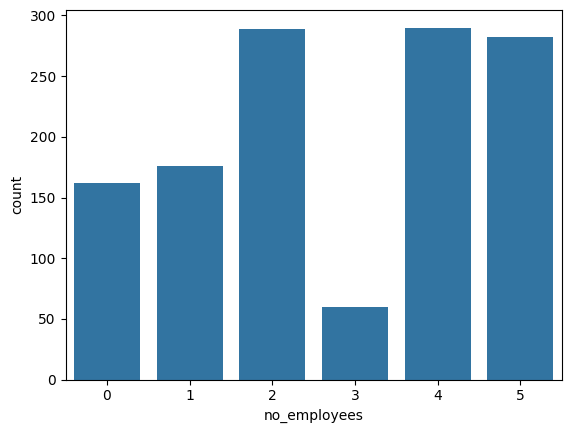

In [21]:
sns.countplot(data=df, x='no_employees')
plt.show()

**ESCALADO Y DIVISIÓN**

In [25]:
X = df.drop('treatment', axis=1)
y = df['treatment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # ← stratify: importante en datos desbalanceados
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entrenamiento y evaluación de modelos

## Regresión logística

In [26]:
m_log = LogisticRegression(max_iter=1000)  # ← max_iter=100 puede no converger
m_log.fit(X_train_scaled, y_train)
pred_log = m_log.predict(X_test_scaled)
acc_log = accuracy_score(y_test, pred_log)

## Árbol de Decisión


In [27]:
m_tree = DecisionTreeClassifier(max_depth=5, random_state=42)
m_tree.fit(X_train, y_train)
pred_tree = m_tree.predict(X_test)
acc_tree = accuracy_score(y_test, pred_tree)

In [29]:
print("\n" + "="*45)
print("     CONSOLIDADO DE CIENCIA DE DATOS")
print("="*45)
print(f"Filas procesadas con éxito : {len(df)}")
print(f"Rango de Edad final        : {df['Age'].min()} a {df['Age'].max()} años")
print("-"*45)
print(f"EFICIENCIA REGRESIÓN LOGÍSTICA : {acc_log:.4f}  ({acc_log*100:.1f}%)")
print(f"EFICIENCIA ÁRBOL DE DECISIÓN   : {acc_tree:.4f}  ({acc_tree*100:.1f}%)")
print("-"*45)

# Reporte detallado para el modelo ganador
mejor_pred = pred_log if acc_log >= acc_tree else pred_tree
print("\nReporte detallado del mejor modelo:")
print(classification_report(y_test, mejor_pred, target_names=['No tratamiento', 'Con tratamiento']))


     CONSOLIDADO DE CIENCIA DE DATOS
Filas procesadas con éxito : 1259
Rango de Edad final        : 18 a 72 años
---------------------------------------------
EFICIENCIA REGRESIÓN LOGÍSTICA : 0.6825  (68.3%)
EFICIENCIA ÁRBOL DE DECISIÓN   : 0.8214  (82.1%)
---------------------------------------------

Reporte detallado del mejor modelo:
                 precision    recall  f1-score   support

 No tratamiento       0.92      0.69      0.79       124
Con tratamiento       0.76      0.95      0.84       128

       accuracy                           0.82       252
      macro avg       0.84      0.82      0.82       252
   weighted avg       0.84      0.82      0.82       252



In [31]:
# 3. Comparación de modelos
modelos = ['Regresión\nLogística', 'Árbol de\nDecisión']
accs = [acc_log, acc_tree]
bars = axes[2].bar(modelos, accs, color=['#4C72B0', '#DD8452'])
axes[2].set_ylim(0.5, 1.0)
axes[2].set_title('Precisión de Modelos')
axes[2].set_ylabel('Accuracy')
for bar, acc in zip(bars, accs):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('resultados_survey.png', dpi=150, bbox_inches='tight')
plt.show()



<Figure size 640x480 with 0 Axes>


Gráfica guardada como 'resultados_survey.png'


In [32]:
plt.show()